In [3]:
import math
from math import ceil, sqrt
from typing import List, Optional, Tuple, Dict, Any

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Rectangle, Circle
from hydrax.utils.files import get_data_path
import pandas as pd
import pprint
from hydrax.utils.files import get_data_path
import seaborn as sns

from matplotlib.ticker import FuncFormatter

data_path = get_data_path()

In [4]:

import pickle


seed = 10
algos = ["mtp"]



In [5]:
costs = np.zeros((len(algos), 5, 401))

for algo, idx in zip(algos, range(len(algos))):
    for nbr_elites, idx_elites in zip([8, 16, 32, 64, 128], range(5)):
        path = data_path / f"pushT_sim_elites_sweep/{algo}/seed_{seed}_n_{nbr_elites}.pkl"
        with open(path, "rb") as f:
            obj = pickle.load(f)
            costs[idx, idx_elites, :] = np.array([step["state_cost"] for step in obj])

(1, 5, 401)


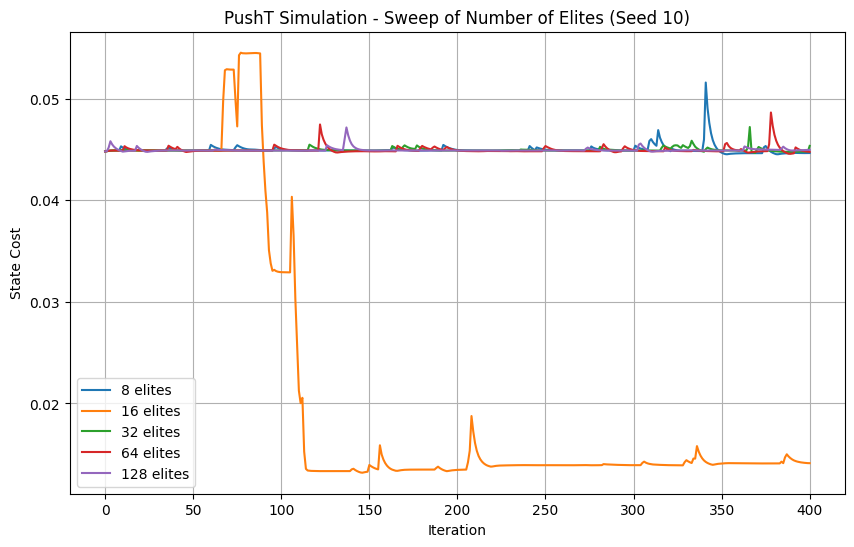

In [6]:
print(costs.shape)
# plot with line for each number of elites
plt.figure(figsize=(10, 6))
for idx_elites, nbr_elites in zip(range(5), [8, 16, 32, 64, 128]):
    plt.plot(costs[0, idx_elites, :], label=f"{nbr_elites} elites")
plt.xlabel("Iteration")
plt.ylabel("State Cost")
plt.title(f"PushT Simulation - Sweep of Number of Elites (Seed {seed})")
plt.legend()
plt.grid()
plt.show()